# Geometry vs actuation: what actually drives the response?

The day-3 take-2 replicate broke the clean day-# trends, and it was a thick (0.70 mm) sample. Here we
ask whether **sample geometry** (thickness, cross-section area, L0) explains the actuation and
electrochemistry better than **fixation day** does, across all 5 samples (days 1, 2, 3, 3-take2, 4).

Same pipeline as the other notebooks (MAD outlier filter -> global linear-slippage correction ->
final cycle). For each sample we take the final-cycle **swing (max - min)** of:
- **stress** (MPa) and **strain** (%) — these are *normalized* (stress = force/area, strain = disp/L0),
  so any correlation of stress with area or strain with L0 is partly built-in; read them with that caveat.
- **force** (mN) and **displacement** (mm) — the *raw, un-normalized* mechanical response, the honest
  thing to regress against geometry.
- plus electrochemical **cathodic peak prominence**, **Epc**, **anodic charge Qa**, **loop area**.

We scatter each against thickness and area (with linear fits + Pearson r/p) and finish with a
correlation table comparing all predictors.

In [1]:
BASE = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.16.26_formalin_fixed_decell_chicken_experiments'

In [2]:
# Config: per-SAMPLE map (mechanical scope + potentiostat), calibration, geometry from sizes.csv.
import os, io, csv
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks
from scipy import stats

SCAN_RATE_V_PER_S    = 0.0025
FORCE_GAIN_MN_PER_V  = 56.7
LENGTH_COEF_MM_PER_V = -0.4130
WINDOW, K            = 41, 5.0
V_TOP                = 0.98
SMOOTH_WINDOW, SAVGOL_POLY = 101, 3

sizes = pd.read_csv(os.path.join(BASE, 'sizes.csv')).set_index('formalin_fixation_time')

SAMPLES = [
    dict(sid='1_DAY', day=1, key='1_DAY', label='1-day',
         fs ='1day_10%_formalin_fixed_FORCE_scope_log_20260618_115506.csv',
         ls ='1day_10%_formalin_fixed_LENGTH_scope_log_20260618_131839.csv',
         fp ='potentiostat/06.18.26-1Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         lp ='potentiostat/06.18.26-1Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='2_DAY', day=2, key='2_DAY', label='2-day',
         fs ='2day_10%_formalin_fixed_FORCE_scope_log_20260615_134504_2Day_10%_formalin_2.5mVperSecond_FORCE.csv',
         ls ='2day_10%_formalin_fixed_LENGTHscope_log_20260615_170309_2Day_10%_formalin_2.5mVperSecond_LENGTH.csv',
         fp ='potentiostat/06.15.26-2Day-formalin-decell_tissue-FORC-2.5mvperSec.csv',
         lp ='potentiostat/06.15.26-2Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY', day=3, key='3_DAY', label='3-day t1',
         fs ='3day_10%_formalin_fixed_FORCE_scope_log_20260617_135652.csv',
         ls ='3day_10%_formalin_fixed_LENGTH_scope_log_20260617_153455.csv',
         fp ='potentiostat/06.17.26-3Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         lp ='potentiostat/06.17.26-3Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='3_DAY_take_2', day=3, key='3_DAY_take_2', label='3-day t2',
         fs ='3day_take2_10%)formalin_fixed_FORCE_scope_log_20260619_135752.csv',
         ls ='3day_take2_10%_formalin_fixed_LENGTH_scope_log_20260619_152237.csv',
         fp ='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         lp ='potentiostat/06.19.26-3Day-take2-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
    dict(sid='4_DAY', day=4, key='4_DAY', label='4-day',
         fs ='4day_10%_formalin_fixed_FORCE_scope_log_20260616_141521.csv',
         ls ='4day_10%_formalin_fixed_LENGTH_scope_log_20260616_154045.csv',
         fp ='potentiostat/06.16.26-4Day-formalin-decell_tissue-FORCE-2.5mvperSec.csv',
         lp ='potentiostat/06.16.26-4Day-formalin-decell_tissue-LENGTH-2.5mvperSec.csv'),
]
DAY_COLOR = {1: '#9467bd', 2: '#1f77b4', 3: '#d62728', 4: '#2ca02c'}

# Pure distilled-PPy film (2026-06-03, -25 C), a small-cross-section anchor for the area axis.
# Geometry per user: W=3.0 mm, T=0.028 mm, L0=3.5 mm -> A=0.084 mm^2. Not a formalin sample (no 'day').
CP = '/Users/yitong/Documents/GitHub/chicken_necrobots/cold_pyrrole_in_tissue_experiments_5.22.26/'
DISTILLED = dict(label='distilled PPy', L0=3.5, W=3.0, T=0.028,
    fs=CP+'scope_log_20260603_141224_distilled_pyrrole_neg25C_synthesis_2.5mVperSec.csv',
    ls=CP+'scope_log_20260603_160853_neg25C-distilledppy_golden_child_LENGTH.csv',
    fp=CP+'Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_FORC_2.5mVpersec.csv',
    lp=CP+'Potentiostat_measurements/06.03.26-neg25C_distilledpyrrole_LENGTH_2.5mVpersec.csv')

# Needle-thru-polymerized decell tissue (2026-06-22), a large-cross-section anchor (A=2.182 mm^2).
# Geometry per user: W=2.7 mm, T=0.808 mm, L0=7.0 mm. Decell tissue but a different polymerization
# method (needle threaded through), so kept OUT of the tissue-only fit and drawn as a test point.
NT = '/Users/yitong/Documents/GitHub/chicken_necrobots/6.18.26_misc_experiments/'
NEEDLE = dict(label='needle-thru', L0=7.0, W=2.7, T=0.808,
    fs=NT+'6.22.26_needle_thru_polymerization_FORCE_scope_log_20260622_133652.csv',
    ls=NT+'6.22.26_needle_thru_polymerization_LENGTH_scope_log_20260622_150048.csv',
    fp=NT+'potentiostat/06.22.26-decell-tissue-with_needl_thru-FORCE-2.5mvperSec.csv',
    lp=NT+'potentiostat/06.22.26-decell-tissue-with_needl_thru-LENGTH-2.5mvperSec.csv')

In [3]:
# Processing helpers (mechanical slippage-corrected final-cycle swing + electrochemical metrics).
def mark_outliers(x, window=41, k=5.0):
    s = pd.Series(x)
    med = s.rolling(window, center=True, min_periods=1).median()
    ad = (s - med).abs()
    mad = ad.rolling(window, center=True, min_periods=1).median().clip(lower=max(np.nanstd(x)*1e-3, 1e-9))
    return (ad > k * mad).values

def savgol_per_cycle(df, col, window=SMOOTH_WINDOW, poly=SAVGOL_POLY):
    out = pd.Series(np.nan, index=df.index)
    for cyc, sub in df.groupby('cycle'):
        sub = sub.sort_values('t_exp'); y = sub[col].values; nn = len(y)
        if nn < 3:
            out.loc[sub.index] = y; continue
        w = min(window, nn); w -= (w % 2 == 0)
        out.loc[sub.index] = savgol_filter(y, w, poly) if w > poly else y
    return out

def _poten(path):
    text = open(os.path.join(BASE, path), 'rb').read().decode('utf-16').replace('﻿', '')
    rows = [r for r in csv.reader(io.StringIO('\n'.join(text.splitlines()[6:]))) if r and r[0]]
    n = len(rows[0]) // 2
    arr = np.array([[float(x) for x in r[:2*n]] for r in rows])
    return arr, n

def mech_swing(scope_csv, poten_csv, channel, coef):
    """Final-cycle slippage-corrected swing of the physical signal (units of coef)."""
    arr, n = _poten(poten_csv)
    v1 = arr[:, 0]; turn = int(np.argmin(v1))
    DT = abs(v1[0] - v1[turn]) / turn / SCAN_RATE_V_PER_S
    per = len(arr) * DT; total = n * per
    t_full = np.concatenate([np.arange(len(arr))*DT + s*per for s in range(n)])
    v_full = np.concatenate([arr[:, 2*s] for s in range(n)])
    sc = pd.read_csv(os.path.join(BASE, scope_csv)); sc['t_exp'] = sc['elapsed_s']
    sc = sc[(sc['t_exp'] >= 0) & (sc['t_exp'] <= total)].copy()
    sc = sc.loc[~mark_outliers(sc[channel].values, WINDOW, K)].copy()
    sc['v_applied'] = np.interp(sc['t_exp'].values, t_full, v_full)
    sc['cycle'] = np.clip((sc['t_exp'].values // per).astype(int), 0, n-1)
    t0 = sc['t_exp'].min(); top = sc[sc['v_applied'] >= V_TOP]
    b, a = np.polyfit(top['t_exp'].values, top[channel].values, 1)
    sc['val'] = (sc[channel] - b*(sc['t_exp'] - t0)) * coef
    sc['sm'] = savgol_per_cycle(sc, 'val')
    sub = sc[sc['cycle'] == n-1]
    return float(sub['sm'].max() - sub['sm'].min())

def _smooth(y, w=51, p=3):
    nn = len(y); w = min(w, nn if nn % 2 else nn-1); w -= (w % 2 == 0)
    return savgol_filter(y, w, p) if w > p else y

def echem(path):
    arr, n = _poten(path)
    v = arr[:, 2*(n-1)]; i = arr[:, 2*(n-1)+1]; turn = int(np.argmin(v))
    DT = abs(v[0]-v[turn])/turn/SCAN_RATE_V_PER_S
    span = i.max()-i.min()
    rv, ri = v[:turn+1], i[:turn+1]
    pk, pr = find_peaks(-_smooth(ri), prominence=0.02*span)
    if len(pk):
        k = np.argmax(pr['prominences']); Epc = float(rv[pk[k]]); prom = float(pr['prominences'][k])
    else:
        Epc, prom = float(rv[np.argmin(_smooth(ri))]), np.nan
    Qa = float(np.sum(i[i > 0]) * DT) / 1000.0
    _tr = getattr(np, 'trapezoid', getattr(np, 'trapz', None))
    return Epc, prom, Qa, float(abs(_tr(i, v)))

In [4]:
# Build the per-sample table: geometry + mechanical swings + electrochemical metrics.
rows = []
for s in SAMPLES:
    g = sizes.loc[s['key']]
    L0, W, T = float(g['length(mm)']), float(g['width(mm)']), float(g['thickness(mm)'])
    area = W * T
    force_mN = mech_swing(s['fs'], s['fp'], 'ch2_MEAN_V', FORCE_GAIN_MN_PER_V)
    dist_mm  = mech_swing(s['ls'], s['lp'], 'ch1_MEAN_V', LENGTH_COEF_MM_PER_V)
    ef = echem(s['fp']); el = echem(s['lp'])     # average FORCE-run & LENGTH-run echem
    Epc, prom, Qa, loop = [np.mean(x) for x in zip(ef, el)]
    rows.append(dict(label=s['label'], day=s['day'], L0_mm=L0, width_mm=W, thickness_mm=T,
                     area_mm2=round(area, 4),
                     stress_delta_MPa=force_mN/area/1000.0, strain_delta_pct=dist_mm/L0*100.0,
                     force_delta_mN=force_mN, dist_delta_mm=dist_mm,
                     prom_cathodic=prom, Epc=Epc, Qa_mC=Qa, loop_area_uAV=loop))
geo = pd.DataFrame(rows).sort_values(['day', 'label']).reset_index(drop=True)

# --- two extra predictors requested ---
# (1) Instron Young's modulus averaged per fixation day, DAY1-2 outlier excluded
#     (from 6.22.26_ppy_muslce_instron_experiments / instron_force_displacement.ipynb).
#     Day 3's two CV samples (t1, t2) both inherit the day-3 mean.
YOUNGS_E_BY_DAY = {1: 3.71, 2: 0.59, 3: 3.84, 4: 3.62}        # MPa
geo['E_MPa_dayavg'] = geo['day'].map(YOUNGS_E_BY_DAY)
# (2) Hours between electropolymerization and when this sample's CV force/length run was taken (per user).
HRS_SINCE_ELECTROPOL = {'2-day': 0, '4-day': 24, '3-day t1': 48, '1-day': 72, '3-day t2': 96}
geo['hrs_since_electropol'] = geo['label'].map(HRS_SINCE_ELECTROPOL)

pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('Per-sample geometry + actuation + electrochemistry (+ day-avg modulus, hrs since electropol):')
geo

Per-sample geometry + actuation + electrochemistry (+ day-avg modulus, hrs since electropol):


,label,day,L0_mm,width_mm,thickness_mm,area_mm2,stress_delta_MPa,strain_delta_pct,force_delta_mN,dist_delta_mm,prom_cathodic,Epc,Qa_mC,loop_area_uAV,E_MPa_dayavg,hrs_since_electropol
0,1-day,1,7.0000,4.0000,0.3600,1.4400,0.0096,0.3523,13.8403,0.0247,694.0714,-0.5869,896.0785,2353.2265,3.7100,72
1,2-day,2,9.0000,2.8000,0.4500,1.2600,0.0187,0.5298,23.5770,0.0477,904.5433,-0.4624,771.7858,2416.3052,0.5900,0
2,3-day t1,3,5.0000,3.1000,0.4260,1.3206,0.0090,0.6613,11.8312,0.0331,919.3364,-0.4525,1066.2973,2644.3610,3.8400,48
3,3-day t2,3,11.0000,2.5000,0.6960,1.7400,0.0046,0.1106,8.0013,0.0122,434.4291,-0.6856,753.1920,1469.9437,3.8400,96
4,4-day,4,11.0000,3.4000,0.3740,1.2716,0.0229,0.7095,29.1361,0.0780,1573.5643,-0.4079,1172.1272,4504.5504,3.6200,24


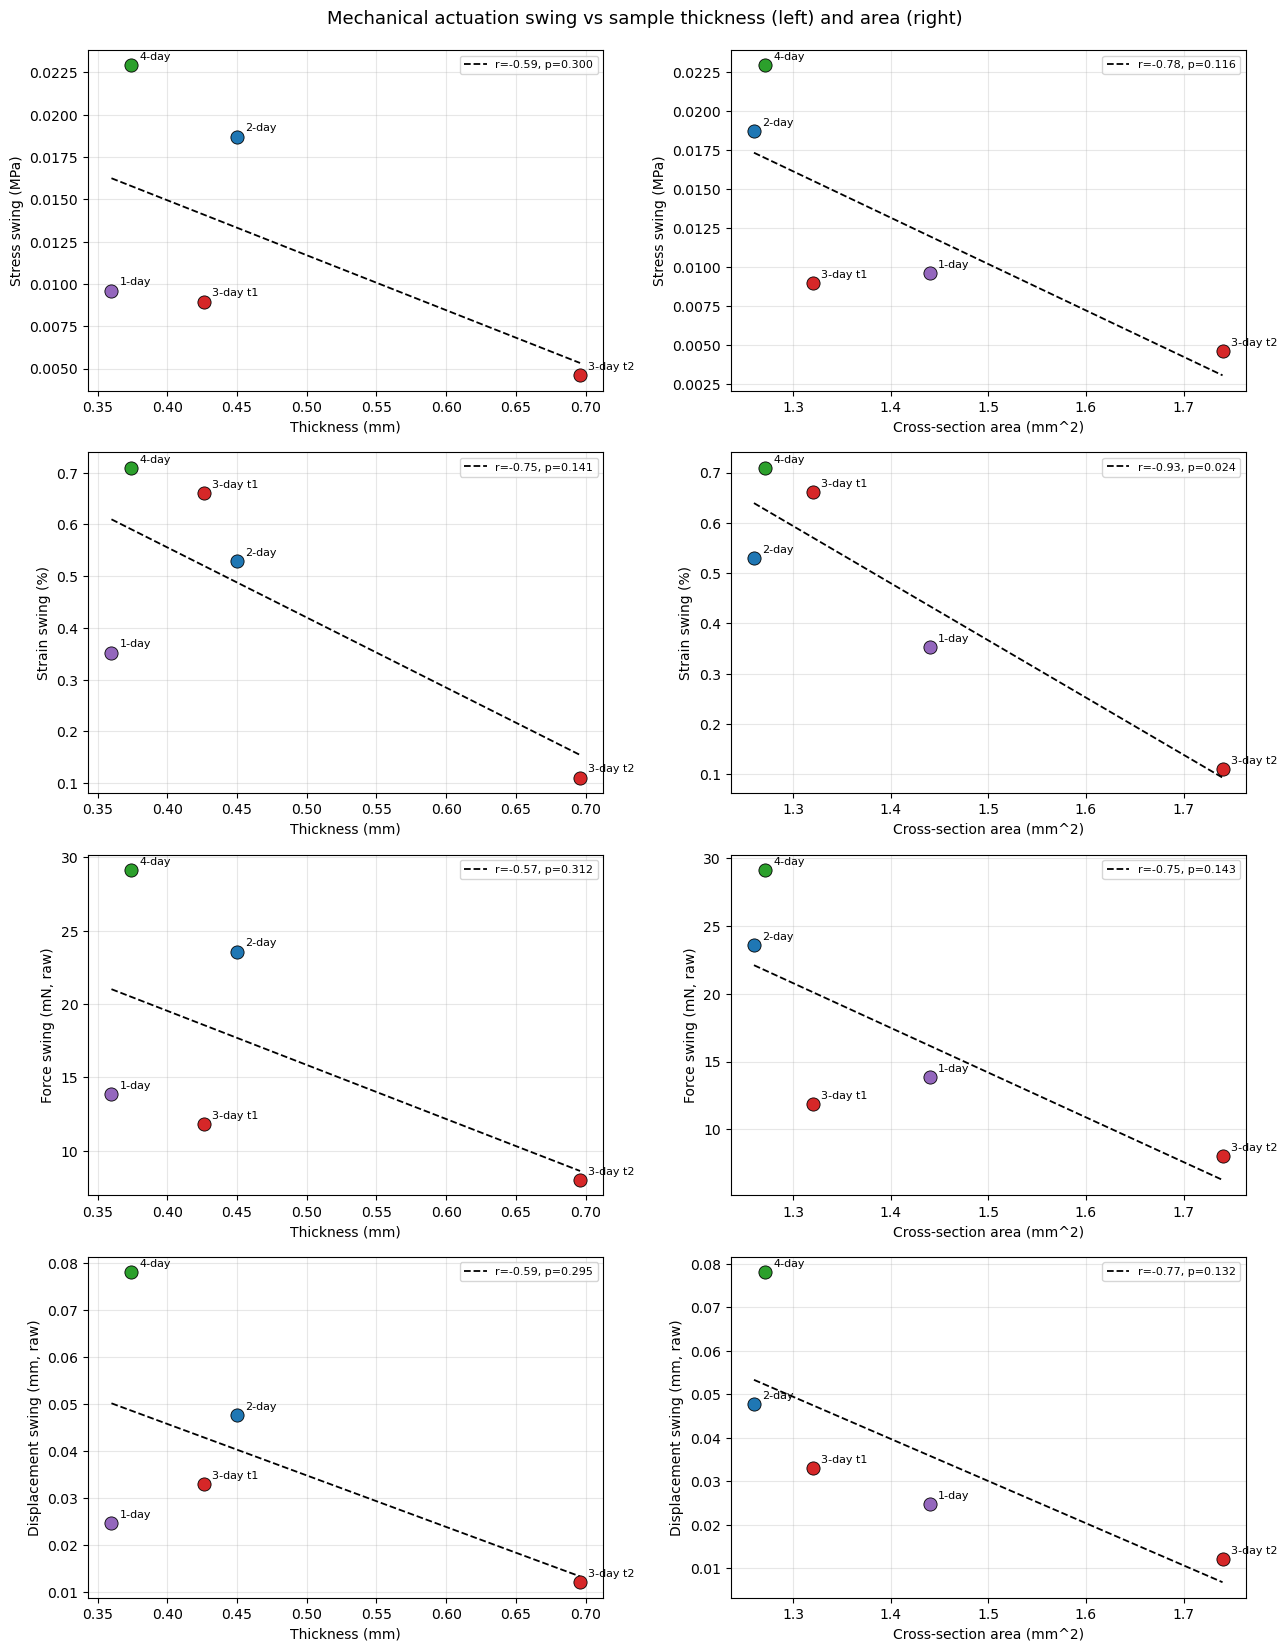

In [5]:
# Scatter each response vs thickness and vs area, with linear fit + Pearson r/p. Color by day.
def scat(ax, xcol, ycol, xlabel, ylabel):
    x = geo[xcol].values.astype(float); y = geo[ycol].values.astype(float)
    for _, r in geo.iterrows():
        ax.scatter(r[xcol], r[ycol], s=90, color=DAY_COLOR[r['day']], ec='k', lw=0.6, zorder=4)
        ax.annotate(r['label'], (r[xcol], r[ycol]), textcoords='offset points', xytext=(6, 4), fontsize=8)
    sl, ic, rr, p, se = stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 40)
    ax.plot(xs, ic + sl*xs, 'k--', lw=1.3, label=f'r={rr:+.2f}, p={p:.3f}')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

RESP = [('stress_delta_MPa', 'Stress swing (MPa)'),
        ('strain_delta_pct', 'Strain swing (%)'),
        ('force_delta_mN',   'Force swing (mN, raw)'),
        ('dist_delta_mm',    'Displacement swing (mm, raw)')]
fig, axes = plt.subplots(len(RESP), 2, figsize=(13, 4.2*len(RESP)))
for row, (col, lab) in enumerate(RESP):
    scat(axes[row, 0], 'thickness_mm', col, 'Thickness (mm)', lab)
    scat(axes[row, 1], 'area_mm2',     col, 'Cross-section area (mm^2)', lab)
fig.suptitle('Mechanical actuation swing vs sample thickness (left) and area (right)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.985]); plt.show()

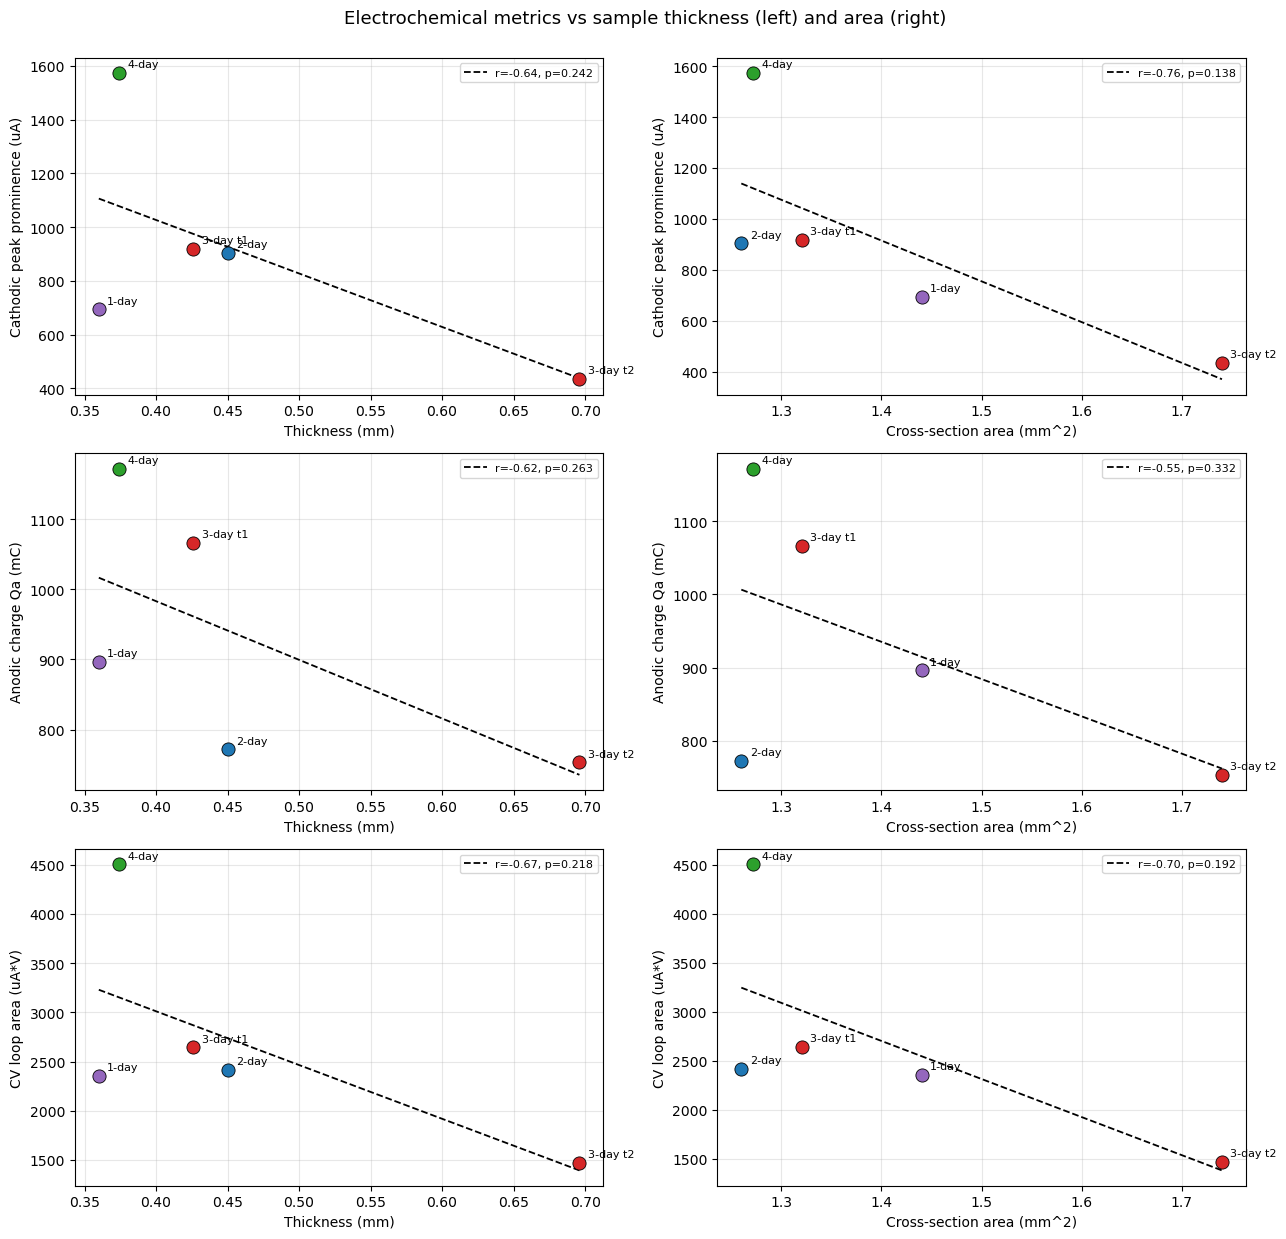

In [6]:
# Same, for the electrochemical metrics vs thickness and area.
RESP_E = [('prom_cathodic', 'Cathodic peak prominence (uA)'),
          ('Qa_mC',         'Anodic charge Qa (mC)'),
          ('loop_area_uAV', 'CV loop area (uA*V)')]
fig, axes = plt.subplots(len(RESP_E), 2, figsize=(13, 4.2*len(RESP_E)))
for row, (col, lab) in enumerate(RESP_E):
    scat(axes[row, 0], 'thickness_mm', col, 'Thickness (mm)', lab)
    scat(axes[row, 1], 'area_mm2',     col, 'Cross-section area (mm^2)', lab)
fig.suptitle('Electrochemical metrics vs sample thickness (left) and area (right)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

## Variable key

All quantities are per CV sample (final cycle). **Responses** are what we measure; **predictors** are
what we correlate them against.

**Mechanical responses** (from the scope force/length sensor, slippage-corrected final-cycle swing = max - min):
- `stress_delta_MPa` - stress swing (FORCE run), = force swing / cross-section area. **MPa**
- `strain_delta_pct` - strain swing (LENGTH run), = displacement swing / gauge length. **%**
- `force_delta_mN` - raw force swing, un-normalized. **mN**
- `dist_delta_mm` - raw displacement swing, un-normalized. **mm**

**Electrochemical responses** (from the potentiostat CV, averaged over the sample's FORCE-run & LENGTH-run):
- `Epc` - **cathodic peak potential**: the voltage where the reduction current peaks on the +1->-1 V sweep.
  **V**. Less negative = reduction happens more easily / more reversibly.
- `prom_cathodic` - **cathodic peak prominence**: height of that reduction peak above its local baseline
  (`scipy.signal.find_peaks`). **uA**. The "intensity" of the redox reaction; bigger = more electroactive.
  *(The anodic side has no interior peak - current just rises to the +1 V vertex - so the clean faradaic
  feature is the cathodic peak. Full derivation in `potentiostat_cv_comparison.ipynb`.)*
- `Qa_mC` - **anodic voltammetric charge**: integral of positive (oxidation) current over time. **mC**.
  How much charge the polymer exchanges per cycle ~ how much active material is doped/de-doped.
- `loop_area_uAV` - **CV hysteresis-loop area** = enclosed area of the current-vs-voltage loop. **uA*V**.
  Single-number "how electrochemically active is this CV"; bigger loop = more charge/energy per cycle.

**Predictors** (what each response is regressed against):
- `day` - formalin-fixation day (1-4).
- `L0_mm`, `width_mm`, `thickness_mm`, `area_mm2` - sample geometry (area = width x thickness).
- `E_MPa_dayavg` - per-day mean Young's modulus from the Instron tensile tests (DAY1-2 outlier excluded). **MPa**
- `hrs_since_electropol` - hours between electropolymerization and this sample's CV force/length run. **hr**


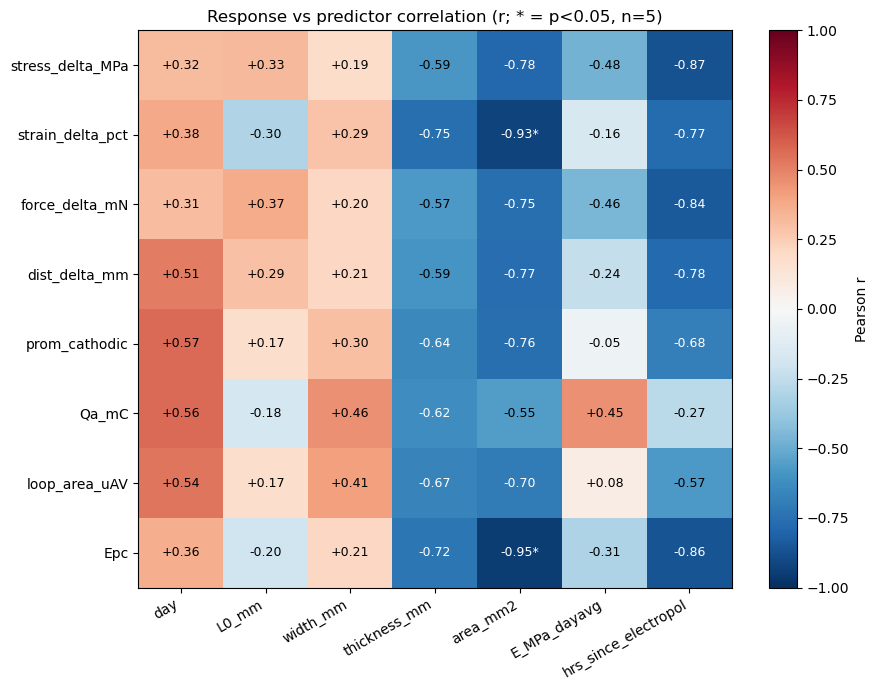

Pearson r table (response rows x predictor cols):


,day,L0_mm,width_mm,thickness_mm,area_mm2,E_MPa_dayavg,hrs_since_electropol
stress_delta_MPa,0.3200,0.3300,0.1900,-0.5900,-0.7800,-0.4800,-0.8700
strain_delta_pct,0.3800,-0.3000,0.2900,-0.7500,-0.9300,-0.1600,-0.7700
force_delta_mN,0.3100,0.3700,0.2000,-0.5700,-0.7500,-0.4600,-0.8400
dist_delta_mm,0.5100,0.2900,0.2100,-0.5900,-0.7700,-0.2400,-0.7800
prom_cathodic,0.5700,0.1700,0.3000,-0.6400,-0.7600,-0.0500,-0.6800
Qa_mC,0.5600,-0.1800,0.4600,-0.6200,-0.5500,0.4500,-0.2700
loop_area_uAV,0.5400,0.1700,0.4100,-0.6700,-0.7000,0.0800,-0.5700
Epc,0.3600,-0.2000,0.2100,-0.7200,-0.9500,-0.3100,-0.8600


\nBest |r| predictor for each response:
  stress_delta_MPa   -> hrs_since_electropol (r=-0.87)
  strain_delta_pct   -> area_mm2      (r=-0.93)
  force_delta_mN     -> hrs_since_electropol (r=-0.84)
  dist_delta_mm      -> hrs_since_electropol (r=-0.78)
  prom_cathodic      -> area_mm2      (r=-0.76)
  Qa_mC              -> thickness_mm  (r=-0.62)
  loop_area_uAV      -> area_mm2      (r=-0.70)
  Epc                -> area_mm2      (r=-0.95)


In [7]:
# Predictor showdown: Pearson r of every response vs every predictor (day vs geometry).
# Bold-ish via a heatmap; '*' marks p < 0.05. n=5, so this is exploratory, not confirmatory.
PREDICTORS = ['day', 'L0_mm', 'width_mm', 'thickness_mm', 'area_mm2', 'E_MPa_dayavg', 'hrs_since_electropol']
RESPONSES  = ['stress_delta_MPa', 'strain_delta_pct', 'force_delta_mN', 'dist_delta_mm',
              'prom_cathodic', 'Qa_mC', 'loop_area_uAV', 'Epc']
Rmat = np.full((len(RESPONSES), len(PREDICTORS)), np.nan)
Pmat = np.full_like(Rmat, np.nan)
for a, resp in enumerate(RESPONSES):
    for b, pred in enumerate(PREDICTORS):
        m = geo[[resp, pred]].dropna()
        if len(m) >= 3:
            r, p = stats.pearsonr(m[resp], m[pred]); Rmat[a, b] = r; Pmat[a, b] = p

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(Rmat, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(PREDICTORS))); ax.set_xticklabels(PREDICTORS, rotation=30, ha='right')
ax.set_yticks(range(len(RESPONSES))); ax.set_yticklabels(RESPONSES)
for a in range(len(RESPONSES)):
    for b in range(len(PREDICTORS)):
        if not np.isnan(Rmat[a, b]):
            star = '*' if Pmat[a, b] < 0.05 else ''
            ax.text(b, a, f'{Rmat[a,b]:+.2f}{star}', ha='center', va='center',
                    color='white' if abs(Rmat[a, b]) > 0.6 else 'black', fontsize=9)
fig.colorbar(im, label='Pearson r'); ax.set_title('Response vs predictor correlation (r; * = p<0.05, n=5)')
fig.tight_layout(); plt.show()

corr_r = pd.DataFrame(Rmat, index=RESPONSES, columns=PREDICTORS)
print('Pearson r table (response rows x predictor cols):')
display(corr_r.round(2))
print('\\nBest |r| predictor for each response:')
for resp in RESPONSES:
    row = corr_r.loc[resp].dropna()
    best = row.abs().idxmax()
    print(f'  {resp:18} -> {best:13} (r={row[best]:+.2f})')

## Time since electropolymerization

`hrs_since_electropol` came out as the strongest predictor of the force/stress channels, so here are stress and strain swing plotted directly against it (color = fixation day). With n=5 and hours confounded with area/day, read this as a flag to control the delay, not proof.

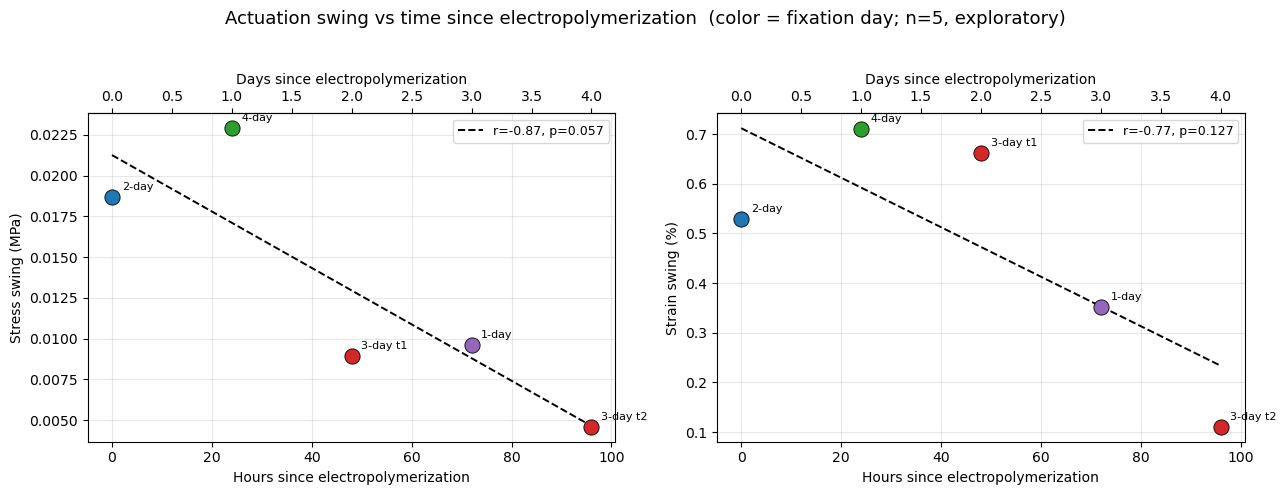

Sorted by time since electropolymerization:


,label,day,hrs_since_electropol,stress_delta_MPa,strain_delta_pct
0,2-day,2,0,0.0187,0.5298
1,4-day,4,24,0.0229,0.7095
2,3-day t1,3,48,0.0090,0.6613
3,1-day,1,72,0.0096,0.3523
4,3-day t2,3,96,0.0046,0.1106


In [8]:
# Stress & strain swing vs time since electropolymerization (hrs_since_electropol just emerged as the
# strongest predictor of the force channels). x in hours; a secondary axis shows the equivalent in days.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (col, lab) in zip(axes, [('stress_delta_MPa', 'Stress swing (MPa)'),
                                  ('strain_delta_pct', 'Strain swing (%)')]):
    x = geo['hrs_since_electropol'].values.astype(float); y = geo[col].values.astype(float)
    for _, r in geo.iterrows():
        ax.scatter(r['hrs_since_electropol'], r[col], s=120, color=DAY_COLOR[r['day']], ec='k', lw=0.6, zorder=5)
        ax.annotate(r['label'], (r['hrs_since_electropol'], r[col]),
                    textcoords='offset points', xytext=(7, 5), fontsize=8)
    sl, ic, rr, p, se = stats.linregress(x, y)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, ic + sl*xs, 'k--', lw=1.4, label=f'r={rr:+.2f}, p={p:.3f}')
    ax.set_xlabel('Hours since electropolymerization'); ax.set_ylabel(lab)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=9)
    sec = ax.secondary_xaxis('top', functions=(lambda h: h/24.0, lambda d: d*24.0))
    sec.set_xlabel('Days since electropolymerization')
fig.suptitle('Actuation swing vs time since electropolymerization  (color = fixation day; n=5, exploratory)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

print('Sorted by time since electropolymerization:')
display(geo[['label', 'day', 'hrs_since_electropol', 'stress_delta_MPa', 'strain_delta_pct']]
        .sort_values('hrs_since_electropol').reset_index(drop=True))

## Area as the predictor (with distilled-PPy & needle-thru anchors)

The plots below put **cross-section area on x** and the two actuation swings on the two y-axes (stress left, strain right), with **linear and quadratic** fits, plus a log-log power-law view. Two off-trend test points bracket the formalin tissue cluster: the pure distilled-PPy film (area 0.084 mm$^2$, star) anchors the small-area end, and the needle-thru decell tissue (area 2.182 mm$^2$, X) anchors the large-area end. Both are drawn as test points; the fits use only the 5 formalin tissue samples.

In [9]:
# Add two off-trend anchors -- the pure distilled-PPy film (small area) and the needle-thru
# tissue (large area) -- then assemble the area-vs-actuation table. Both are drawn as test points;
# the fits below use only the 5 formalin tissue samples.
def _anchor_row(spec):
    A = spec['W'] * spec['T']
    f = mech_swing(spec['fs'], spec['fp'], 'ch2_MEAN_V', FORCE_GAIN_MN_PER_V)   # mN
    d = mech_swing(spec['ls'], spec['lp'], 'ch1_MEAN_V', LENGTH_COEF_MM_PER_V)  # mm
    return dict(label=spec['label'], day=np.nan, L0_mm=spec['L0'], width_mm=spec['W'],
                thickness_mm=spec['T'], area_mm2=round(A, 4),
                stress_delta_MPa=f/A/1000.0, strain_delta_pct=d/spec['L0']*100.0,
                force_delta_mN=f, dist_delta_mm=d,
                prom_cathodic=np.nan, Epc=np.nan, Qa_mC=np.nan, loop_area_uAV=np.nan)

area_df = pd.concat([geo, pd.DataFrame([_anchor_row(DISTILLED), _anchor_row(NEEDLE)])],
                    ignore_index=True)
area_df['is_distilled'] = area_df['label'] == DISTILLED['label']
area_df['is_needle']    = area_df['label'] == NEEDLE['label']
area_df['in_fit']       = ~(area_df['is_distilled'] | area_df['is_needle'])   # fit = 5 formalin tissue samples
print('Stress / strain swing vs cross-section area (5 formalin tissue + distilled-PPy + needle-thru anchors):')
display(area_df[['label', 'area_mm2', 'thickness_mm', 'stress_delta_MPa', 'strain_delta_pct']].round(4))

Stress / strain swing vs cross-section area (5 formalin tissue + distilled-PPy + needle-thru anchors):


,label,area_mm2,thickness_mm,stress_delta_MPa,strain_delta_pct
0,1-day,1.4400,0.3600,0.0096,0.3523
1,2-day,1.2600,0.4500,0.0187,0.5298
2,3-day t1,1.3206,0.4260,0.0090,0.6613
3,3-day t2,1.7400,0.6960,0.0046,0.1106
4,4-day,1.2716,0.3740,0.0229,0.7095
5,distilled PPy,0.0840,0.0280,0.7802,8.1695
6,needle-thru,2.1816,0.8080,0.0033,0.2671


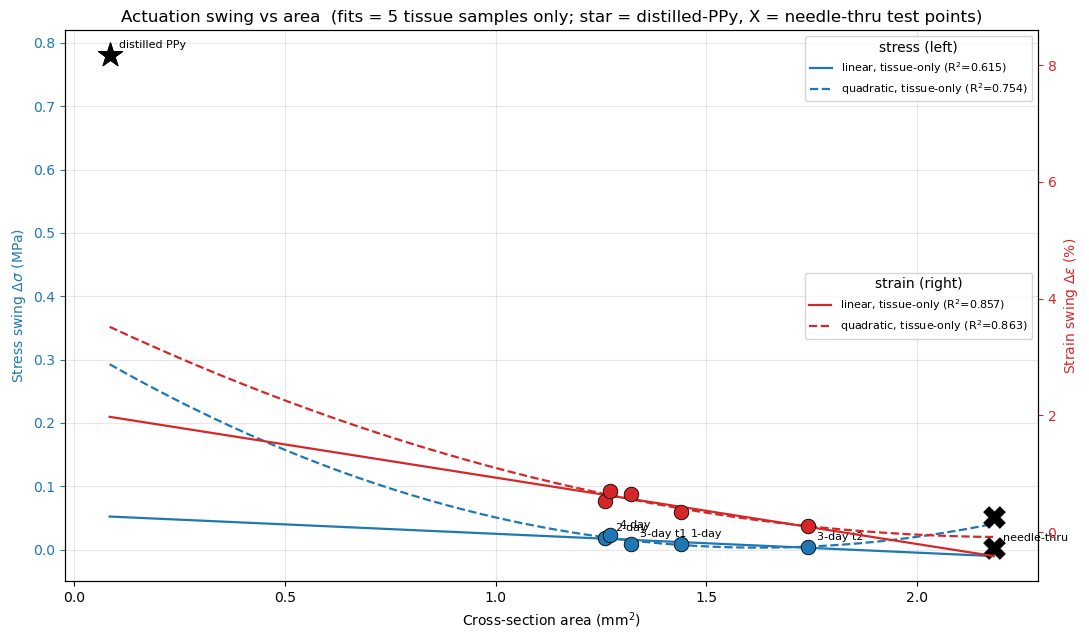

distilled PPy at area = 0.084 mm^2 vs the tissue-only fit extrapolated there:
  stress (MPa): actual=   0.780 | linear pred=   0.052 (ABOVE)  quad pred=   0.293 (ABOVE)
  strain  (%) : actual=   8.170 | linear pred=   1.977 (ABOVE)  quad pred=   3.519 (ABOVE)
needle-thru at area = 2.182 mm^2 vs the tissue-only fit extrapolated there:
  stress (MPa): actual=   0.003 | linear pred=  -0.010 (ABOVE)  quad pred=   0.041 (below)
  strain  (%) : actual=   0.267 | linear pred=  -0.409 (ABOVE)  quad pred=  -0.082 (ABOVE)


In [10]:
# THE area plot: x = cross-section area; left y = stress swing (MPa), right y = strain swing (%).
# Linear (solid) and quadratic (dashed) fits for each. Distilled PPy = star; tissue circles colored by day.
def _r2(y, yhat):
    y = np.asarray(y, float); ss = np.sum((y - y.mean())**2)
    return 1 - np.sum((y - yhat)**2)/ss if ss > 0 else np.nan

TIS = area_df['in_fit'].values                   # the 5 decell-tissue samples (excludes both anchors)

def fit_lin_quad(ax, xall, yall, color):
    """Fit on the 5 tissue samples ONLY, but draw the curve across the full area range so the
    distilled-PPy (small area) and needle-thru (large area) points read as above/below the trend."""
    xf, yf = xall[TIS], yall[TIS]
    xs = np.linspace(xall.min(), xall.max(), 200)
    cl = np.polyfit(xf, yf, 1); ax.plot(xs, np.polyval(cl, xs), color=color, ls='-', lw=1.6,
        label=f'linear, tissue-only (R$^2$={_r2(yf, np.polyval(cl, xf)):.3f})')
    cq = np.polyfit(xf, yf, 2); ax.plot(xs, np.polyval(cq, xs), color=color, ls='--', lw=1.6,
        label=f'quadratic, tissue-only (R$^2$={_r2(yf, np.polyval(cq, xf)):.3f})')
    return cl, cq

def _anchor_marker(r):
    if r['is_distilled']: return '*', 340
    if r['is_needle']:    return 'X', 240
    return 'o', 110

STRESS_C, STRAIN_C = '#1f77b4', '#d62728'
x = area_df['area_mm2'].values
fig, axL = plt.subplots(figsize=(11, 6.5)); axR = axL.twinx()

# scatter (markers: star = distilled PPy, X = needle-thru, circle = formalin tissue)
for _, r in area_df.iterrows():
    mk, sz = _anchor_marker(r); anchor = r['is_distilled'] or r['is_needle']
    fc_s = 'k' if anchor else STRESS_C
    fc_e = 'k' if anchor else STRAIN_C
    axL.scatter(r['area_mm2'], r['stress_delta_MPa'], marker=mk, s=sz, color=fc_s, ec='k', lw=0.6, zorder=5)
    axR.scatter(r['area_mm2'], r['strain_delta_pct'], marker=mk, s=sz, color=fc_e, ec='k', lw=0.6, zorder=5)
    axL.annotate(r['label'], (r['area_mm2'], r['stress_delta_MPa']),
                 textcoords='offset points', xytext=(7, 5), fontsize=8)

cl_s, cq_s = fit_lin_quad(axL, x, area_df['stress_delta_MPa'].values, STRESS_C)
cl_e, cq_e = fit_lin_quad(axR, x, area_df['strain_delta_pct'].values, STRAIN_C)

axL.set_xlabel('Cross-section area (mm$^2$)')
axL.set_ylabel('Stress swing $\\Delta\\sigma$ (MPa)', color=STRESS_C); axL.tick_params(axis='y', colors=STRESS_C)
axR.set_ylabel('Strain swing $\\Delta\\varepsilon$ (%)', color=STRAIN_C); axR.tick_params(axis='y', colors=STRAIN_C)
axL.grid(True, alpha=0.3)
axL.legend(title='stress (left)', loc='upper right', fontsize=8)
axR.legend(title='strain (right)', loc='center right', fontsize=8)
axL.set_title('Actuation swing vs area  (fits = 5 tissue samples only; star = distilled-PPy, X = needle-thru test points)')
fig.tight_layout(); plt.show()

# Where do the two off-trend anchors land relative to the tissue-only trend, extrapolated to their area?
for _, anc in area_df[~area_df['in_fit']].iterrows():
    xa = float(anc['area_mm2'])
    print(f"{anc['label']} at area = {xa:.3f} mm^2 vs the tissue-only fit extrapolated there:")
    for lab, col, cl, cq in [('stress (MPa)', 'stress_delta_MPa', cl_s, cq_s),
                             ('strain  (%) ', 'strain_delta_pct', cl_e, cq_e)]:
        act = float(anc[col]); pl = float(np.polyval(cl, xa)); pq = float(np.polyval(cq, xa))
        rel = lambda p: 'ABOVE' if act > p else 'below'
        print(f'  {lab}: actual={act:8.3f} | linear pred={pl:8.3f} ({rel(pl)})  quad pred={pq:8.3f} ({rel(pq)})')

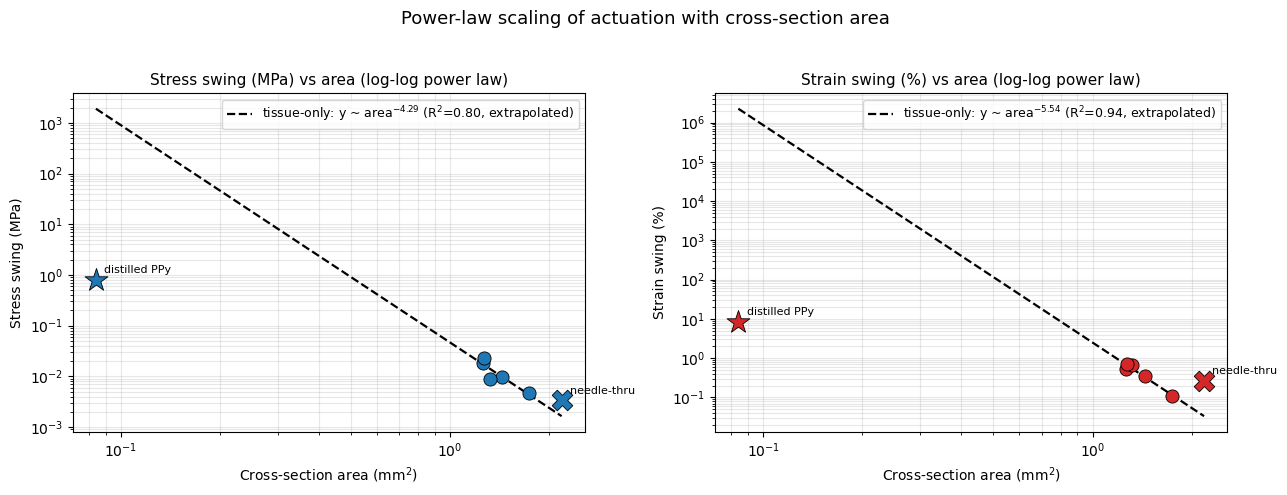

In [11]:
# Physics check: is the falloff ~1/area (slope -1) or ~1/area^2 (slope -2)? A log-log power-law fit
# reads the exponent directly. Diffusion-limited charging scales with a length^2, so an exponent near
# -1 (area) or -2 (a squared length) is the interesting regime. (n=6, distilled dominates the range.)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (col, lab, color) in zip(axes,
        [('stress_delta_MPa', 'Stress swing (MPa)', STRESS_C),
         ('strain_delta_pct', 'Strain swing (%)', STRAIN_C)]):
    x = area_df['area_mm2'].values; y = area_df[col].values
    for _, r in area_df.iterrows():
        if r['is_distilled']: mk, sz = '*', 300
        elif r['is_needle']:  mk, sz = 'X', 220
        else:                 mk, sz = 'o', 90
        ax.scatter(r['area_mm2'], r[col], marker=mk, s=sz, color=color, ec='k', lw=0.6, zorder=5)
        if r['is_distilled'] or r['is_needle']:
            ax.annotate(r['label'], (r['area_mm2'], r[col]), textcoords='offset points', xytext=(6, 5), fontsize=8)
    xt, yt = x[TIS], y[TIS]                               # power law fit on tissue samples only
    m, b = np.polyfit(np.log(xt), np.log(yt), 1)          # log y = m log x + b  -> y = e^b * x^m
    r2 = _r2(np.log(yt), m*np.log(xt) + b)
    xs = np.logspace(np.log10(x.min()), np.log10(x.max()), 100)
    ax.plot(xs, np.exp(b) * xs**m, 'k--', lw=1.6,
            label=f'tissue-only: y ~ area$^{{{m:.2f}}}$ (R$^2$={r2:.2f}, extrapolated)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Cross-section area (mm$^2$)'); ax.set_ylabel(lab)
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=9)
    ax.set_title(f'{lab} vs area (log-log power law)', fontsize=11)
fig.suptitle('Power-law scaling of actuation with cross-section area', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

## Reading the geometry correlation

- **Raw force / displacement swings** vs thickness & area are the honest test — they have no built-in
  normalization. If those track thickness/area more tightly than they track day, geometry is the real
  driver and "fixation day" was partly a stand-in for "which sample happened to be thicker/thinner".
- **Stress** divides by area and **strain** divides by L0, so `stress~area` and `strain~L0` carry a
  built-in component — don't over-read those two specific pairings.
- The **correlation table** lists, for each response, the predictor with the largest |r|. With only
  5 samples (and day 3 contributing two), every r here is exploratory — treat it as a hypothesis
  generator for which variable to control next, not proof.
- If electrochemical metrics (prominence, Qa, loop area) also track thickness, that points to a
  diffusion / accessible-volume mechanism: thicker samples are harder to fully oxidize/reduce at
  2.5 mV/s, giving both weaker redox and weaker actuation — consistent with the 3-day take-2 outlier.

### Area plot + distilled-PPy & needle-thru anchors
- The **pure distilled-PPy film** (area 0.084 mm$^2$) sits ~15x below the tissue cluster in area and
  ~30-150x above it in stress/strain swing — a strong small-area, high-actuation anchor.
- The **needle-thru decell tissue** (area 2.182 mm$^2$) anchors the *large*-area end, just past the
  formalin cluster (1.26-1.74 mm$^2$). It's decell tissue but a different polymerization method, so it's
  drawn as a test point (X) rather than folded into the fit. Read whether it lands above/below the
  tissue trend extrapolated to its area (printed below the plot) — together with distilled PPy it brackets
  the tissue range on both sides, which is the real value of these two anchors.
- **The linear & quadratic fits use only the 5 decell-tissue samples**; distilled PPy (star) and
  needle-thru (X) are plotted as test points so you can read whether each lands **above or below** the
  tissue-derived trend. The tissue area range is narrow, so extrapolating to either anchor is a stretch —
  treat "above/below" qualitatively.
- The **log-log power-law exponent** (also tissue-only) is the physically meaningful number: ~-1 means
  response ~ 1/area; steeper (toward -2) hints at a squared-length (diffusion) limit. The clean test is a
  thickness/area sweep at fixed material, or slowing the scan rate.